# 02. Neural Network Classification with Pytorch

## 1. Make classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles

#Make 1000 samples
n_samples=1000

#Create circles
X,y=make_circles(n_samples, noise=0.03, random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"First five samples of X:\n{X[:5]}")
print(f"First five samples of y:\n{y[:5]}")

First five samples of X:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First five samples of y:
[1 1 1 1 0]


In [5]:
# make dataframe from circles data
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0], "X2":X[:,1], "label":y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


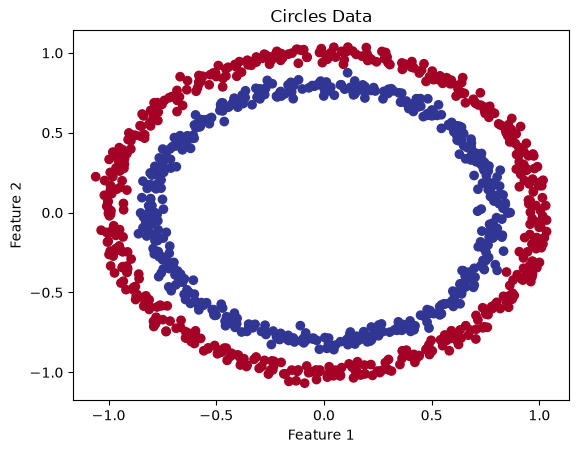

In [6]:
#visualize the data
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Circles Data")
plt.show()

**Note:** The data we are working with is also known as toy dataset. A dataset that is small enough to experiment but still sizeable enough to practice the fundamentals

### 1.1 check inp and out shape

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [9]:
#view the first 5 labels
X_sample=  X[0]
y_sample=  y[0]

print(f"Values for one sample of X:\n{X_sample} and the same for y:\n{y_sample}")
print(f"Shape of one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X:
[0.75424625 0.23148074] and the same for y:
1
Shape of one sample of X: (2,) and the same for y: ()


### 2. Turn data into tensors

In [10]:
#turn data into tensors
import torch
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

In [12]:
# split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Lets build a model to classify our blue and red dots
to do so we want to:
1. Set up device agnostic code so our code will run on an accelerator(gpu) if there is one
2. Construct a model(by subclassing nn.Module)
3. Define a loss function and optimizer
4. Create a traning and test loop

In [14]:
# import pytorch and nn
import torch
from torch import nn

# make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [15]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we have setup device agnostic code lets create a model that:
1. Subclasses 'nn.Module' (almost all models in Pytorch subclass 'nn.Module)
2. Create 2 'nn.Linear()' layers that are capable of handling the shapes of our data
3. Defube a forward() method that outlines the forward pass(or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target device

In [16]:
#1. Construct a model by subclassing nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2, out_features=5) # takes in 2 features and outputs 5 features
        self.layer_2=nn.Linear(in_features=5, out_features=1) # takes in 5 features and outputs 1 feature( same shape as y)
    
    # define forward function to define how data moves through the model
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) #x->layer_1-->layer_2-->output

# Instantiate the model and send it to the target device
model_0=CircleModelV0().to(device)
model_0        

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
device

'cuda'

In [18]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [19]:
# Lets replicate the model above using nn.sequential
model_0=nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [20]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2451, -0.4405],
                      [ 0.6436, -0.0043],
                      [-0.3501, -0.2486],
                      [ 0.5532, -0.0831],
                      [-0.3696,  0.4185]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.5284, -0.3889,  0.5270,  0.6943, -0.3163], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.1797, -0.2568, -0.2434, -0.2737, -0.3069]], device='cuda:0')),
             ('1.bias', tensor([0.1508], device='cuda:0'))])

In [21]:
# make predictions
untrained_preds=model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape:{X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape:torch.Size([200, 2])

First 10 predictions:
tensor([[ 0.1010],
        [ 0.0036],
        [ 0.2771],
        [ 0.0515],
        [ 0.1508],
        [ 0.0923],
        [-0.0821],
        [-0.0617],
        [ 0.2821],
        [-0.0044]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [22]:
X_test[:10],y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function and optimizer

Which loss func and optimizer?

For regression : MAE or MSE

For classification : Binary cross entropy or cross entropy

And for optimizer two common are SGD and Adam

For loss func we are going to use 'torch.nn.BCEWithLogitsLoss()'

In [23]:
# set up loss func
#loss_fn=nn.BCELoss() ## requires inputs to have gone thru the sigmoid activation function prior to input to BCELoss
loss_fn=nn.BCEWithLogitsLoss() #BCEWithLoss= sigmoid activation function built-in

optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.01)

In [24]:
# calculate accuracy
def accuracy_fn(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc

## 3. Train model

To train our model we need to build a training loop with same loop structure as used before

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**

We can convert these logits into prediction probabilities by passing them to some kind of activation function (e.g sigmoid for binary classification and softmax for multiclass classification)

Then we can convert our models prediction probabilities to prediction labels by either rounding them or taking the argmax()

In [26]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits=model_0(X_test.to(device))[:5]
y_logits

tensor([[0.1010],
        [0.0036],
        [0.2771],
        [0.0515],
        [0.1508]], device='cuda:0')

In [27]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [28]:
# use sigmoid act func on our model
y_pred_probs=torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5252],
        [0.5009],
        [0.5688],
        [0.5129],
        [0.5376]], device='cuda:0')

For our prediction probabaility value we need to perform a range-style rounding on them:
* y_pred_probs >= 0.5 , y=1(class 1)
* y_preb_probs <0.5, y=0 (class 0)

In [ ]:
# find the pred label
y_preds=torch.round(y_pred_probs)

# in full(logits->pred probs-> pred labels)
y_pred_labels=torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

#check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0')

In [33]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### 3.2 Building a training and testing loop

In [37]:
print(X_train.device)
print(y_train.device)
print(next(model_0.parameters()).device)
print(y_logits.device)


cuda:0
cpu
cuda:0
cuda:0


In [38]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set epochs
epochs=100

# put data to target device
X_train, y_train=X_train.to(device), y_train.to(device)
X_test, y_test= X_test.to(device), y_test.to(device)

#building training and evaluating loop
for epoch in range(epochs):
    model_0.train()

    #Forward pass
    y_logits=model_0(X_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))

    # accuracy
    #loss=loss_fn(torch.sigmoid(y_logits), ## BCELoss expects prediction probability as input
     #            y_train)
    loss=loss_fn(y_logits, ## BCEWithlogits expects logits as raw input
                 y_train)

    acc=accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

    #optimizer zero grad
    optimizer.zero_grad()

    #loss backward
    loss.backward()

    #optimizer step
    optimizer.step()

    #testing
    model_0.eval()
    with torch.inference_mode():
        test_logits=model_0(X_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))

        # calculate test loss
        test_loss=loss_fn(test_logits,
                          y_test)
        test_acc=accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

        # print out whats happen
    if epoch %10==0:
        print(f"Epoch: {epoch} | Loss:{loss:.5f},Accuracy:{acc:.2f}% | Test loss: {test_loss:.5f} , Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss:0.69826,Accuracy:53.50% | Test loss: 0.69273 , Test acc: 53.50%
Epoch: 10 | Loss:0.69788,Accuracy:53.50% | Test loss: 0.69249 , Test acc: 54.50%
Epoch: 20 | Loss:0.69754,Accuracy:52.88% | Test loss: 0.69229 , Test acc: 52.00%
Epoch: 30 | Loss:0.69724,Accuracy:52.88% | Test loss: 0.69212 , Test acc: 52.00%
Epoch: 40 | Loss:0.69697,Accuracy:53.12% | Test loss: 0.69197 , Test acc: 52.50%
Epoch: 50 | Loss:0.69673,Accuracy:52.12% | Test loss: 0.69185 , Test acc: 52.00%
Epoch: 60 | Loss:0.69652,Accuracy:51.50% | Test loss: 0.69174 , Test acc: 51.50%
Epoch: 70 | Loss:0.69632,Accuracy:51.75% | Test loss: 0.69165 , Test acc: 51.50%
Epoch: 80 | Loss:0.69615,Accuracy:51.62% | Test loss: 0.69158 , Test acc: 51.50%
Epoch: 90 | Loss:0.69599,Accuracy:52.00% | Test loss: 0.69152 , Test acc: 52.00%


## 4. Make predictions and evaluate the model

From metrics it looks like our model is not learning anything

So inspect it by visualizing

To do so we are going to import a function called plot_decision_boundary()

In [42]:
import requests
from pathlib import Path
#download helper function from learn pytorch repo (if it is not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_function.py already exist , skipping download")
else:
    print("Download helper_function.py")
    request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py") 
    with open("helper_function.py", "wb") as f:
        f.write(request.content)   

from helper_function import plot_predictions, plot_decision_boundary        

Download helper_function.py


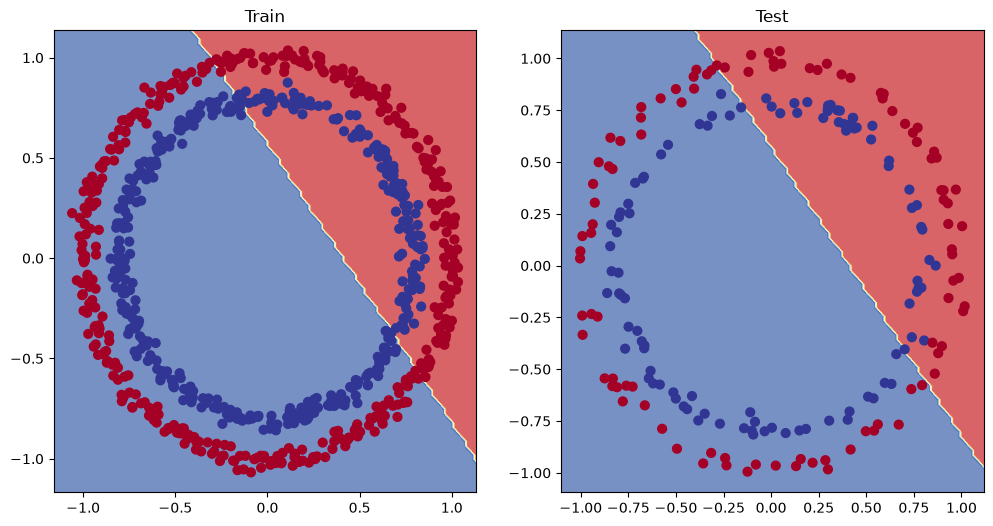

In [43]:
# plot decision boundary of model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)

## 5. Improving a Model

* Add more hidden layers so that it can learn more
* Add more hidden units
* Fit for longer
* Changing th activation function
* Changing the learning rate
* Change the loss function

These options are all from model perspective because they deal directly with the model, rather than th data

And bcz these options are all values we (as machine learning engineers) can change, they are referred as hyperparameters

Lets try to improve model by:
* Adding more hidden units: 5-> 10
* Increase the number of layers : 2->3
* Increase the number of epochs: 100-> 1000

In [45]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2, out_features=10)
        self.layer_2=nn.Linear(in_features=10, out_features=10)
        self.layer_3=nn.Linear(in_features=10, out_features=1)

    def forward(self,x):
        #z=self.layer_1(x)
        #z=self.layer_2(z)
       # z=z=self.layer_3(z)
       return self.layer_3(self.layer_2(self.layer_1(x))) # this way of writing operation leverages speed up

model_1=CircleModelV1().to(device)
model_1    


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [46]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2422, -0.4377],
                      [ 0.6393, -0.0084],
                      [-0.3546, -0.2529],
                      [ 0.5483, -0.0877],
                      [-0.3749,  0.4135]])),
             ('0.bias', tensor([ 0.5247, -0.3834,  0.5327,  0.7005, -0.3095])),
             ('1.weight',
              tensor([[ 0.1565, -0.2372, -0.2655, -0.2810, -0.2996]])),
             ('1.bias', tensor([0.1287]))])

In [47]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [48]:
# create a loss function
loss_fn=nn.BCEWithLogitsLoss()

#create a optimizer
optimizer=torch.optim.SGD(params=model_1.parameters(),
                          lr=0.1)


In [50]:
# Training and evaluation loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#train longer
epochs=1000

# Put data on the target device
X_train, y_train=X_train.to(device), y_train.to (device)
X_test, y_test=X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()
    y_logits=model_1(X_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))
    loss=loss_fn(y_logits, y_train)
    acc=accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    model_1.eval()
    with torch.inference_mode():
        test_logits-model_1(X_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))
        test_loss=loss_fn(test_logits,
                          y_test)
        test_acc=accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    if epoch % 10==0:
        print(f"Epoch: {epoch} | Loss:{loss:.5f},Accuracy:{acc:.2f}% | Test loss: {test_loss:.5f} , Test acc: {test_acc:.2f}%")           


Epoch: 0 | Loss:0.69396,Accuracy:50.88% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 10 | Loss:0.69369,Accuracy:50.25% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 20 | Loss:0.69351,Accuracy:50.12% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 30 | Loss:0.69339,Accuracy:50.50% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 40 | Loss:0.69329,Accuracy:50.38% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 50 | Loss:0.69322,Accuracy:49.88% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 60 | Loss:0.69317,Accuracy:49.38% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 70 | Loss:0.69312,Accuracy:49.38% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 80 | Loss:0.69309,Accuracy:50.12% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 90 | Loss:0.69307,Accuracy:50.50% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 100 | Loss:0.69305,Accuracy:50.38% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 110 | Loss:0.69303,Accuracy:50.88% | Test loss: 0.69147 , Test acc: 51.50%
Epoch: 120 | Loss:0.69302,A

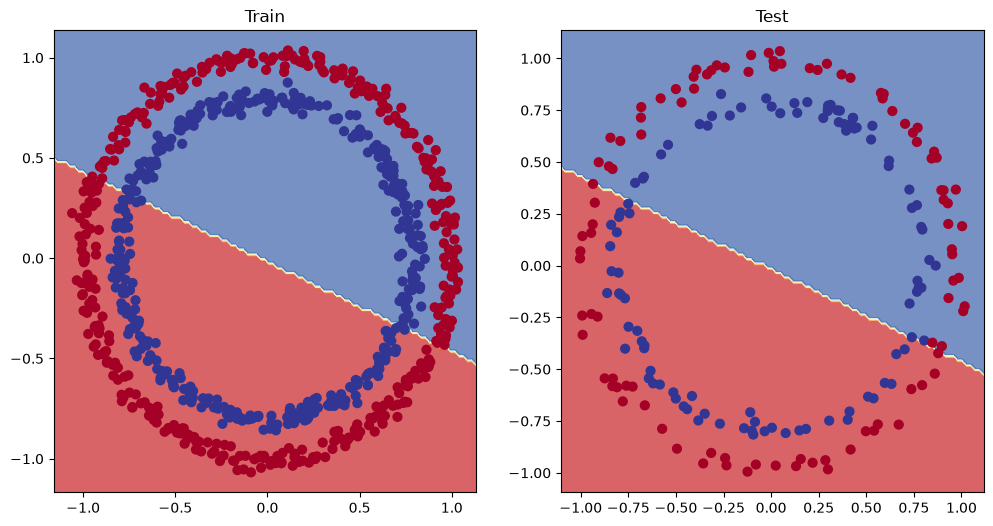

In [51]:
# plot decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

### 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot to a larger problem is to test a smaller problem

In [52]:
# create some data(same as noteboke 01 )
weight=0.7
bias=0.3
start=0
end=1
step=0.01

# create data
x_regression=torch.arange(start, end,step).unsqueeze(dim=1)
y_regression=weight*x_regression+bias

# check data
print(len(x_regression))
x_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [53]:
# create train and test splits
train_split=int(0.8*len(x_regression))
x_train_regression, y_train_regression = x_regression[:train_split], y_regression[:train_split]
x_test_regression, y_test_regression= x_regression[train_split:],y_regression[train_split:]

# check the lenghts
len(x_test_regression), len(x_train_regression), len(y_train_regression),len(y_test_regression)

(20, 80, 80, 20)

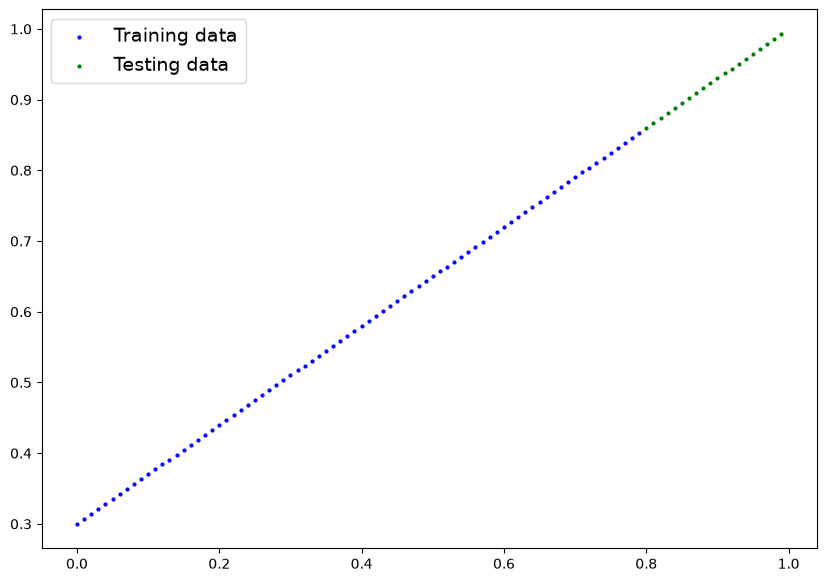

In [55]:
plot_predictions(train_data=x_train_regression,
                train_labels=y_train_regression,
                test_data=x_test_regression,
                test_labels=y_test_regression)

In [56]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

### 5.2 Adjusting  'model_1' to fit a straight line

In [58]:
# same architecture as model_1 but using nn.Sequential()
model_2=nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [62]:
# loss and optimizer
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_2.parameters(),
                          lr=0.01)

In [63]:
# train
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set epochs
epochs=1000

# put data on target device
x_train_regression, y_train_regression= x_train_regression.to(device), y_train_regression.to(device)
x_test_regression, y_test_regression=x_test_regression.to(device), y_test_regression.to(device)

# training
for epoch in range(epochs):
    y_pred=model_2(x_train_regression)
    loss=loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # testing
    model_2.eval()
    with torch.inference_mode():
        test_pred=model_2(x_test_regression)
        test_loss=loss_fn(test_pred, y_test_regression)

    # print
    if epoch %10==0:
        
        print(f"Epoch: {epoch} | Loss:{loss:.5f} | Test loss: {test_loss:.5f} ")           
        
   

Epoch: 0 | Loss:0.03930 | Test loss: 0.00505 
Epoch: 10 | Loss:0.00258 | Test loss: 0.01056 
Epoch: 20 | Loss:0.00270 | Test loss: 0.01212 
Epoch: 30 | Loss:0.00278 | Test loss: 0.01183 
Epoch: 40 | Loss:0.00286 | Test loss: 0.01157 
Epoch: 50 | Loss:0.00293 | Test loss: 0.01131 
Epoch: 60 | Loss:0.00301 | Test loss: 0.01124 
Epoch: 70 | Loss:0.00309 | Test loss: 0.01095 
Epoch: 80 | Loss:0.00317 | Test loss: 0.01070 
Epoch: 90 | Loss:0.00325 | Test loss: 0.01044 
Epoch: 100 | Loss:0.00332 | Test loss: 0.01017 
Epoch: 110 | Loss:0.00339 | Test loss: 0.00993 
Epoch: 120 | Loss:0.00346 | Test loss: 0.00968 
Epoch: 130 | Loss:0.00353 | Test loss: 0.00966 
Epoch: 140 | Loss:0.00361 | Test loss: 0.00940 
Epoch: 150 | Loss:0.00368 | Test loss: 0.00914 
Epoch: 160 | Loss:0.00375 | Test loss: 0.00890 
Epoch: 170 | Loss:0.00382 | Test loss: 0.00866 
Epoch: 180 | Loss:0.00388 | Test loss: 0.00844 
Epoch: 190 | Loss:0.00394 | Test loss: 0.00822 
Epoch: 200 | Loss:0.00401 | Test loss: 0.00823 
Epo

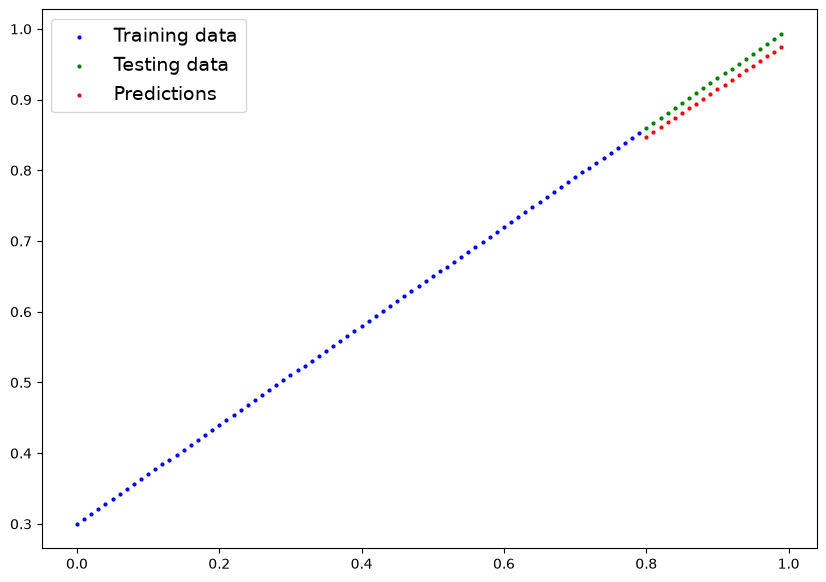

In [65]:
# turn on evaluation mode
model_2.eval()

with torch.inference_mode():
    y_preds=model_2(x_test_regression)

# plot data and predictions
plot_predictions(train_data=x_train_regression.cpu(),  ## plot predictions uses matplot lib which accepts numbers as numpy thats why converting to cpu
                 train_labels=y_train_regression.cpu(),
                 test_data=x_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());    